In [1]:
# ==============================================================================
# 1. IMPORTS & GLOBAL SETUP
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

# Set random seeds for reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
seed_everything(42)

# Global Constants
DATA_DIR = "/kaggle/input/datasets/spark2025/spark-2026-chestxray/dataset"
IMG_SIZE = 224
BATCH_SIZE = 64  # 2x GPUs: 64 images/batch (32 per GPU)
NUM_CLASSES = 2
EPOCHS = 50
LEARNING_RATE = 1e-4

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using Device: {DEVICE}")

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported succesfully!")

[INFO] Using Device: cuda
Libraries imported succesfully!


In [2]:
# manually computing mean and std of images instead of static values
# temporary composer
temp_composer = transforms.Compose([
    v2.ToImage(),
    v2.Resize(size=(224, 224), antialias=True),
    v2.ToDtype(torch.float32, scale=True),  # scalling [0, 1]
])

train_dataset = ImageFolder(root="/kaggle/input/datasets/spark2025/spark-2026-chestxray/dataset/train", transform=temp_composer)
temp_loader = DataLoader(train_dataset, batch_size=32)

def statistics_per_channel(images, labels):  
    # NCHW
    n_samples, n_channels, n_height, n_width = images.size()

    flatten_per_channel = images.reshape(n_samples, n_channels, -1)

    # computing statistics of each image per channels
    
    means = flatten_per_channel.mean(axis=2)

    stds = flatten_per_channel.std(axis=2)

    sum_means = means.sum(axis=0)
    sum_stds = stds.sum(axis=0)

    n_samples = torch.tensor([n_samples]*n_channels).float()

    return torch.stack([n_samples, sum_means, sum_stds], axis=0)

def loader_apply(loader, func, reduce='sum'):
    results = [func(x, y) for i, (x, y) in enumerate(loader)]
    results = torch.stack(results, axis=0)

    if reduce == "sum":
        results = results.sum(axis=0)

    if reduce == "mean":
        results = results.float().mean(axis=0)

    return results

def make_normalizer(loader):
    total_samples, total_means, total_stds = loader_apply(loader, statistics_per_channel)
    norm_mean = total_means / total_samples
    norm_std = total_stds /total_samples

    return transforms.Normalize(mean=norm_mean, std=norm_std)

# custom normalizer
custom_normalizer = make_normalizer(temp_loader)
custom_normalizer

Normalize(mean=tensor([0.4818, 0.4818, 0.4818]), std=tensor([0.2223, 0.2223, 0.2223]))

In [3]:
# ==============================================================================
# 2. TRANSFORMS & DATA AUGMENTATION (MERCY & AHMED)
# ==============================================================================
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Data augmentation for training to improve model generalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),           # Randomly flip horizontally
    transforms.RandomRotation(15),                    # Slight rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Brightness & Contrast
    transforms.ToTensor(),
    custom_normalizer
])

# Standard transforms for validation and testing (No Augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    custom_normalizer
])

print("[INFO] Transforms Initialized")

[INFO] Transforms Initialized


## 3. Dataset Registration
Since our images are already beautifully organized into `NORMAL` and `PNEUMONIA` subdirectories for the `train` and `val` sets, we don't need a new complex class to load and use them! We can just use standard PyTorch `ImageFolder` class which is significantly cleaner and faster.

In [4]:
# ==============================================================================
# 4. DATALOADER INITIALIZATION (USING IMAGEFOLDER)
# ==============================================================================
from torchvision.datasets import ImageFolder

train_dir = os.path.join(DATA_DIR, 'train')
val_dir   = os.path.join(DATA_DIR, 'val')

# Standard PyTorch ImageFolder binds labels based on Subdirectory structure automatically based on their alphabetical sorting!
# Since "N" comes before "P" in the alphabet: NORMAL becomes the first class [0] & PNEUMONIA becomes the second class [1].

train_dataset = ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = ImageFolder(root=val_dir, transform=val_test_transform)

# Use multiprocessing for data loading
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)


# Count class frequencies in training set
train_labels = [label for _, label in train_dataset]
num_normal = train_labels.count(0)
num_pneumonia = train_labels.count(1)
pos_weight = torch.tensor([num_normal / num_pneumonia]).to(DEVICE)
print(f"[INFO] pos_weight = {pos_weight.item():.4f}")


val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
CLASS_NAMES = train_dataset.classes
print(f"[INFO] DataLoaders built successfully! Classes: {CLASS_NAMES}")
print(f"[INFO] Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

print(train_dataset.class_to_idx)

[INFO] pos_weight = 0.3704
[INFO] DataLoaders built successfully! Classes: ['NORMAL', 'PNEUMONIA']
[INFO] Train batches: 65 | Val batches: 14
{'NORMAL': 0, 'PNEUMONIA': 1}


In [5]:
# ==============================================================================
# 5. CNN ARCHITECTURE (SUPREME)
# ==============================================================================
class ChestXRayCNN(nn.Module):
    def __init__(self):
        super(ChestXRayCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        
        # Block 5
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.pool5 = nn.MaxPool2d(2, 2)
        
        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected Block
        # IMG_SIZE=224 -> halved 5 times: 224->112->56->28->14->7
        self.fc1 = nn.Linear(512 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 1) # Binary output

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        x = self.pool5(F.relu(self.bn5(self.conv5(x))))
        
        x = x.view(-1, 512 * 7 * 7) # Flatten
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        # We output raw logits so we can use BCEWithLogitsLoss during training
        # This is more numerically stable than sigmoid + BCELoss
        x = self.fc2(x)
        return x

# ── Balanced Multi-GPU Loss Wrapper ──────────────────────────────────────────
# When DataParallel splits a batch across GPUs, by default it gathers all outputs
# to GPU 0 before computing loss — giving GPU 0 extra work.
# This wrapper moves loss computation INTO the forward pass so EACH GPU
# computes its own loss on its own 32 images independently.
# DataParallel then just averages two small scalar values → perfectly equal load!
class BalancedCNNWithLoss(nn.Module):
    def __init__(self, base_model, pos_weight=None):
        super(BalancedCNNWithLoss, self).__init__()
        self.model = base_model

        if pos_weight is not None:
            self.criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        else:
            self.criterion = nn.BCEWithLogitsLoss()
            
        # self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, images, labels=None):
        logits = self.model(images)  # [B, 1]
        if labels is not None:
            loss = self.criterion(logits, labels.float().unsqueeze(1))
            return loss, logits
        return logits

# ── Multi-GPU Balanced Setup ──────────────────────────────────────────────────
# DataParallel splits each batch EQUALLY across all available GPUs.
# With 2 T4s and batch_size=64: GPU 0 gets images[0:32], GPU 1 gets images[32:64]
# The heavy computation (5 Conv blocks) runs simultaneously on both cards.
# GPU 0 only gathers the lightweight logit tensors at the end before computing loss.

num_gpus = torch.cuda.device_count()
print(f"[INFO] GPUs available: {num_gpus}")
for g in range(num_gpus):
    print(f"       GPU {g}: {torch.cuda.get_device_name(g)} "
          f"| Memory: {torch.cuda.get_device_properties(g).total_memory / 1e9:.1f} GB")

base_model = ChestXRayCNN()
model = BalancedCNNWithLoss(base_model, pos_weight=pos_weight).to(DEVICE)

if num_gpus > 1:
    # Wrap the ENTIRE model+loss so each GPU computes its own loss equally
    model = nn.DataParallel(model, device_ids=list(range(num_gpus)))
    print(f"\n[INFO] Balanced DataParallel across {num_gpus} GPUs.")
    print(f"       Each batch: {BATCH_SIZE // num_gpus} images → each GPU simultaneously")
    print(f"       Loss computed independently on each GPU → perfectly equal load!")
else:
    print("[INFO] Single GPU detected — DataParallel not used.")

print("\n[INFO] Model (with internal balanced loss) Architecture Initialized:")
print(model)

[INFO] GPUs available: 2
       GPU 0: Tesla T4 | Memory: 15.6 GB
       GPU 1: Tesla T4 | Memory: 15.6 GB

[INFO] Balanced DataParallel across 2 GPUs.
       Each batch: 32 images → each GPU simultaneously
       Loss computed independently on each GPU → perfectly equal load!

[INFO] Model (with internal balanced loss) Architecture Initialized:
DataParallel(
  (module): BalancedCNNWithLoss(
    (model): ChestXRayCNN(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (conv3): Conv2d(64, 128, kernel_size=(3, 3), 

In [6]:
# ==============================================================================
# 6. OPTIMIZED TRAINING LOOP (SETH)
# ==============================================================================
# Loss is now computed inside the model (BalancedCNNWithLoss) for equal GPU load.
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning Rate Scheduler - halves LR if val loss stalls for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
early_stop_patience = 10  # Trigger early stop if no improvement for 6 epochs
epochs_no_improve = 0

def calculate_accuracy(logits, labels):
    preds = torch.sigmoid(logits) >= 0.5
    return (preds.view(-1) == labels.view(-1)).float().mean().item()

print("[INFO] Starting High-Performance Training Loop...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    # ── Train Phase ──────────────────────────────────────────────────────────
    try:
        if 'train_loader' in globals():
            for i, (images, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)):
                images = images.to(DEVICE)
                labels = labels.float().to(DEVICE)

                optimizer.zero_grad()

                # model returns (loss, logits) — each GPU computes its own loss
                loss, outputs = model(images, labels)
                loss = loss.mean()  # Average across GPUs

                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            train_loss = running_loss / len(train_loader)
        else:
            train_loss = 0.0
            print("[WARN] train_loader not defined.")
    except Exception as e:
        print(f"Skipping train phase: {e}")
        break

    # ── Validation Phase ─────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_acc = 0.0

    with torch.no_grad():
        if 'val_loader' in globals():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", leave=False):
                images = images.to(DEVICE)
                labels = labels.float().to(DEVICE)

                loss, outputs = model(images, labels)
                loss = loss.mean()

                val_loss += loss.item()
                val_acc += calculate_accuracy(outputs, labels.unsqueeze(1))

            val_loss = val_loss / len(val_loader)
            val_acc = val_acc / len(val_loader)
        else:
            val_loss = 0.0
            val_acc = 0.0

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Step scheduler
    scheduler.step(val_loss)

    # ── Save Best Model & Early Stopping ──────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"   >>> [*] Best model saved! (Val Loss: {val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"   --- No improvement for {epochs_no_improve}/{early_stop_patience} epochs.")
        if epochs_no_improve >= early_stop_patience:
            print(f"\n[!] EARLY STOPPING at Epoch {epoch+1}. Best Val Loss: {best_val_loss:.4f}")
            break

print("[INFO] Training Complete.")

[INFO] Starting High-Performance Training Loop...


Epoch 1/50 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [1/50] | Train Loss: 0.2052 | Val Loss: 0.1035 | Val Acc: 0.9018
   >>> [*] Best model saved! (Val Loss: 0.1035)


Epoch 2/50 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

...

Epoch 49/50 [Val]:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [49/50] | Train Loss: 0.0510 | Val Loss: 0.0498 | Val Acc: 0.9578
   >>> [*] Best model saved! (Val Loss: 0.0498)


Epoch 50/50 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [50/50] | Train Loss: 0.0472 | Val Loss: 0.0500 | Val Acc: 0.9589
   --- No improvement for 1/10 epochs.
[INFO] Training Complete.


[INFO] Running Comprehensive Evaluation on Validation Set...
[INFO] Best model weights loaded.


Running Evaluation:   0%|          | 0/14 [00:00<?, ?it/s]

  EVALUATION SUMMARY
 Macro F1-Score : 0.9476
 AUC-ROC        : 0.9949

Full Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.95      0.92       237
   PNEUMONIA       0.98      0.96      0.97       641

    accuracy                           0.96       878
   macro avg       0.94      0.96      0.95       878
weighted avg       0.96      0.96      0.96       878



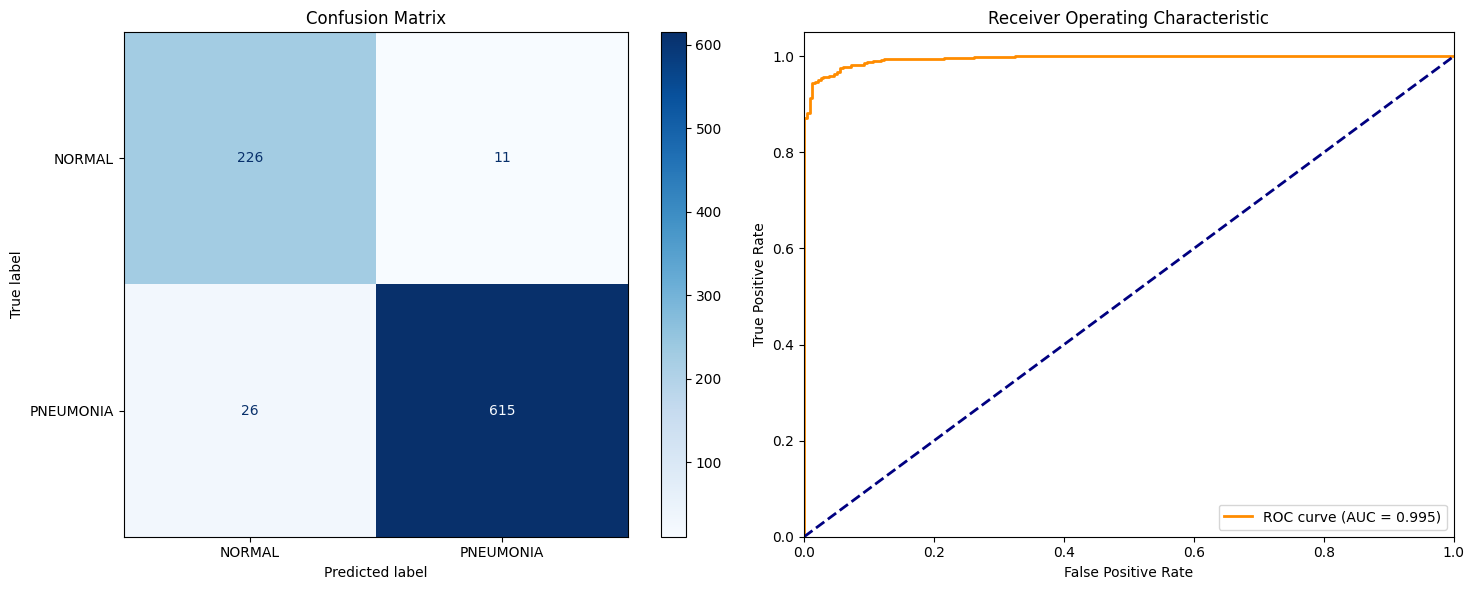

In [7]:
# ==============================================================================
# 7. MODEL EVALUATION (GIDEON)
# ==============================================================================
print("[INFO] Running Comprehensive Evaluation on Validation Set...")

try:
    # Load best weights
    if os.path.exists('best_model.pth'):
        state_dict = torch.load('best_model.pth', map_location=DEVICE)
        
        # FIX: Handle state_dict keys saved from DataParallel (prefixed with 'module.')
        # This converts "module.model.conv1.weight" -> "model.conv1.weight"
        clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        
        if isinstance(model, nn.DataParallel):
            model.module.load_state_dict(clean_state_dict)
        else:
            model.load_state_dict(clean_state_dict)
        print("[INFO] Best model weights loaded.")

    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        if 'val_loader' in globals():
            for images, labels in tqdm(val_loader, desc="Running Evaluation"):
                images = images.to(DEVICE)
                
                logits = model(images)
                # If model returns (loss, logits), extract logits
                if isinstance(logits, tuple):
                    logits = logits[1]
                
                probs = torch.sigmoid(logits).cpu().numpy().flatten()
                preds = (probs >= 0.5).astype(int)
                
                all_labels.extend(labels.numpy().flatten())
                all_preds.extend(preds)
                all_probs.extend(probs)
                
        all_labels = np.array(all_labels)
        all_preds = np.array(all_preds)
        all_probs = np.array(all_probs)

    # Metrics
    if len(all_labels) > 0:
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        auc_score = roc_auc_score(all_labels, all_probs)
        cm = confusion_matrix(all_labels, all_preds)
        
        print("=====================================================")
        print("  EVALUATION SUMMARY")
        print("=====================================================")
        print(f" Macro F1-Score : {f1_macro:.4f}")
        print(f" AUC-ROC        : {auc_score:.4f}")
        print("\nFull Classification Report:")
        print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))
        
        # Visualizations
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # 1. Confusion Matrix
        cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
        cm_display.plot(ax=axes[0], cmap='Blues', colorbar=True)
        axes[0].set_title('Confusion Matrix')
        
        # 2. ROC Curve
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic')
        axes[1].legend(loc="lower right")
        
        plt.tight_layout()
        plt.savefig("evaluation_dashboard.png")
        plt.show()
except Exception as e:
    print(f"[WARN] Evaluation could not be run completely. Ensure data paths are valid. Reason: {e}")

In [8]:
# ==============================================================================
# 8. KAGGLE SUBMISSION GENERATOR
# ==============================================================================
print("[INFO] Generating Predictions for Kaggle Submission...")

# The test.csv acts as our map of which images we need to predict
test_csv_path = os.path.join(DATA_DIR, 'test.csv')
submission_df = pd.read_csv(test_csv_path)

model.eval()
predictions = []

# Using tqdm to track prediction progression
from tqdm.auto import tqdm

with torch.no_grad():
    for idx, row in tqdm(submission_df.iterrows(), total=len(submission_df), desc="Predicting Test Set"):
        # The filepath column contains the relative path (e.g., 'test/CXR_05741.jpeg')
        img_path = os.path.join(DATA_DIR, row['filepath'])
        
        # Load and transform image
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_test_transform(img).unsqueeze(0).to(DEVICE) # Add batch dimension (B, C, H, W)
        
        # Forward pass
        logits = model(img_tensor)
        prob = torch.sigmoid(logits).item()
        
        # Classify: 1 if prob >= 0.5 (PNEUMONIA) else 0 (NORMAL)
        pred = 1 if prob >= 0.5 else 0
        predictions.append(pred)

# Build the submission string format (id, target)
submission_df['target'] = predictions
submission_df = submission_df[['id', 'target']] # Keep only Kaggle-required columns

# Save output
submission_df.to_csv('submission.csv', index=False)
print("[SUCCESS] Saved generated predictions to 'submission.csv'!")
print(submission_df.head())

[INFO] Generating Predictions for Kaggle Submission...


Predicting Test Set:   0%|          | 0/879 [00:00<?, ?it/s]

[SUCCESS] Saved generated predictions to 'submission.csv'!
          id  target
0  CXR_05741       1
1  CXR_03646       1
2  CXR_00870       1
3  CXR_04969       1
4  CXR_01893       1
